# Generation statistics — CarbideMatterGen Stage A (w=1.0 / w=2.5)

Analyses the generated carbide pool and the cheap-screen survivors, mirroring
the analysis depth of OxideMatterGen `15_v6_perov_w1_20k_stats.ipynb`.

Inputs (produced by `scripts/20_generate.sh` + `scripts/30_cheap_screen.py`):
- `outputs/gen/w1p0/chunk_*/...cif`, `outputs/gen/w2p5/chunk_*/...cif` — raw generated structures
- `outputs/gen/screen_w1p0.csv`, `outputs/gen/screen_w2p5.csv` — cheap-screen survivors

Sections: (1) load pools + recompute descriptors, (2) numerical summary,
(3) six-panel Fig-style figure, (4) guidance-weight comparison (w=1.0 vs 2.5),
(5) design-target hit-rates + top HEC candidates.

Re-runnable at any time during generation; it simply analyses whatever chunks
are present. Figures saved to `../figures/`.

In [1]:
import sys, json
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib as mpl, matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

ROOT = Path('/home/jonglee69/mattergen/CarbideMatterGen')
sys.path.insert(0, str(ROOT))
GEN = ROOT / 'outputs' / 'gen'
FIG = ROOT / 'figures'; FIG.mkdir(exist_ok=True)

NATURE_RC = {
    'font.family':'sans-serif','font.sans-serif':['Arial','Helvetica','DejaVu Sans'],
    'font.size':8,'axes.labelsize':8,'axes.titlesize':9,'xtick.labelsize':7,
    'ytick.labelsize':7,'legend.fontsize':7,'axes.linewidth':0.6,
    'xtick.direction':'in','ytick.direction':'in','xtick.top':True,'ytick.right':True,
    'legend.frameon':False,'pdf.fonttype':42,'ps.fonttype':42,
    'savefig.bbox':'tight','savefig.dpi':300,
}
mpl.rcParams.update(NATURE_RC)
OI = {'blue':'#0072B2','vermil':'#D55E00','green':'#009E73','orange':'#E69F00',
      'sky':'#56B4E9','purple':'#CC79A7','yellow':'#F0E442','black':'#000000'}
print('GEN dir:', GEN)

GEN dir: /home/work/CarbideMatterGen/outputs/gen


## 1. Load pools and recompute descriptors

We recompute the composition descriptors directly from the generated CIFs so
the analysis is self-contained (it does not depend on the screen CSV schema).
`is_tm_carbide_composition` is the element-set carbide test (not the buggy
substring one).

In [2]:
from pymatgen.core import Structure
from carbidemattergen.labeling import is_tm_carbide_composition
from carbidemattergen.hydrogen import hydrogen_descriptors, carbon_fraction
from carbidemattergen.extra_descriptors import metal_mixing_entropy, n_metal_species

def load_pool(weight_tag):
    """Recompute composition descriptors for every generated CIF of a weight."""
    wdir = GEN / weight_tag
    files = sorted(wdir.rglob('*.cif'))
    rows = []
    for fp in files:
        try:
            comp = Structure.from_file(str(fp)).composition
        except Exception:
            continue
        h = hydrogen_descriptors(comp)
        rows.append({
            'w': weight_tag, 'formula': comp.reduced_formula,
            'is_carbide': is_tm_carbide_composition(comp),
            'best_site': h['best_site_h_affinity'], 'mean_h': h['mean_h_affinity'],
            'frac_tn': h['frac_thermoneutral_sites'], 'd_band': h['d_band_proxy'],
            'vec': h['valence_electron_conc'], 'xC': carbon_fraction(comp),
            'S_mix': metal_mixing_entropy(comp), 'n_metal': n_metal_species(comp),
        })
    df = pd.DataFrame(rows, columns=['w', 'formula', 'is_carbide', 'best_site', 'mean_h', 'frac_tn', 'd_band', 'vec', 'xC', 'S_mix', 'n_metal'])
    print(f'{weight_tag}: {len(files)} CIFs -> {len(df)} parsed, '
          f'{int(df.is_carbide.sum()) if len(df) else 0} carbides')
    return df

pools = {}
for tag in ('w1p0', 'w2p5'):
    if (GEN / tag).exists():
        pools[tag] = load_pool(tag)
df_all = pd.concat(pools.values(), ignore_index=True) if pools else pd.DataFrame(columns=['w', 'formula', 'is_carbide', 'best_site', 'mean_h', 'frac_tn', 'd_band', 'vec', 'xC', 'S_mix', 'n_metal'])
print('total parsed:', len(df_all))

/home/work/OxideMatterGen/.venv/lib/python3.10/site-packages/pymatgen/io/cif.py:1304: UserWarning: Issues encountered while parsing CIF: 2 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  warnings.warn("Issues encountered while parsing CIF: " + "\n".join(self.warnings))


/home/work/OxideMatterGen/.venv/lib/python3.10/site-packages/pymatgen/io/cif.py:1304: UserWarning: Issues encountered while parsing CIF: 1 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  warnings.warn("Issues encountered while parsing CIF: " + "\n".join(self.warnings))


/home/work/OxideMatterGen/.venv/lib/python3.10/site-packages/pymatgen/io/cif.py:1304: UserWarning: Issues encountered while parsing CIF: 3 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  warnings.warn("Issues encountered while parsing CIF: " + "\n".join(self.warnings))


w1p0: 10000 CIFs -> 10000 parsed, 9461 carbides


w2p5: 10000 CIFs -> 10000 parsed, 9200 carbides
total parsed: 20000


## 2. Numerical summary

Carbide-only subset; `best_site`/`frac_tn` are the primary HER targets.

In [3]:
def summarise(df):
    d = df[df.is_carbide].copy()
    rows = [('n_carbide', len(d), '', '')]
    for col, lab in [('best_site','best-site ΔG_H'),('mean_h','mean ΔG_H'),
                     ('frac_tn','frac thermoneutral'),('S_mix','S_mix (R)'),
                     ('n_metal','n_metal'),('vec','VEC'),('xC','carbon frac')]:
        if col in d.columns and len(d):
            s = d[col].dropna()
            if len(s):
                rows.append((lab, f'{s.mean():.3f}', f'{s.min():.3f}', f'{s.max():.3f}'))
    return pd.DataFrame(rows, columns=['metric','mean','min','max'])

for tag, df in pools.items():
    print(f'=== {tag} (carbide subset) ===')
    print(summarise(df).to_string(index=False))
    print()

=== w1p0 (carbide subset) ===
            metric   mean    min   max
         n_carbide   9461             
    best-site ΔG_H -0.034 -0.450 0.050
         mean ΔG_H -0.036 -0.450 0.225
frac thermoneutral  0.953  0.000 1.000
         S_mix (R)  0.633  0.000 1.631
           n_metal  2.055  1.000 6.000
               VEC  5.365  3.000 9.143
       carbon frac  0.353  0.050 0.750

=== w2p5 (carbide subset) ===
            metric   mean    min   max
         n_carbide   9200             
    best-site ΔG_H -0.029 -0.050 0.050
         mean ΔG_H -0.028 -0.221 0.100
frac thermoneutral  0.999  0.500 1.000
         S_mix (R)  0.743  0.000 1.820
           n_metal  2.370  1.000 7.000
               VEC  5.768  4.000 8.167
       carbon frac  0.287  0.050 0.750



## 3. Six-panel generation-statistics figure

Carbide subset of the combined pool: (a) best-site ΔG_H distribution with Pt
reference, (b) mean vs best-site, (c) entropy vs best-site, (d) metal-count
histogram (OOD reach), (e) VEC vs best-site, (f) carbon fraction.

saved /home/work/CarbideMatterGen/figures/fig6_generation_stats.pdf


saved /home/work/CarbideMatterGen/figures/fig6_generation_stats.png


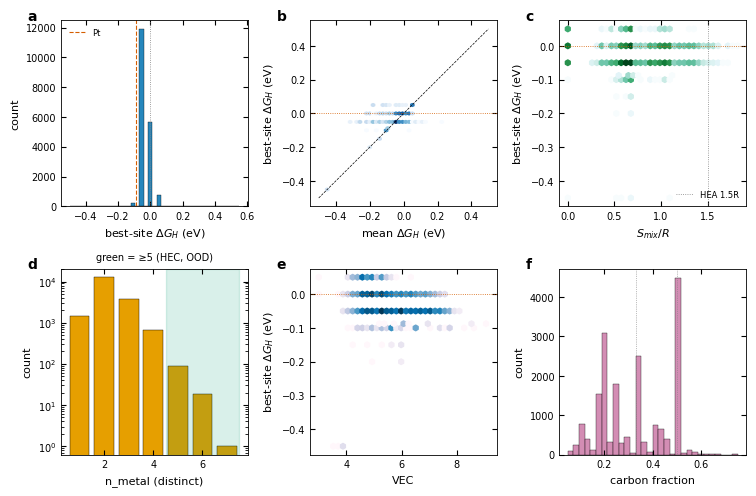

In [4]:
d = df_all[df_all.is_carbide].copy() if len(df_all) else pd.DataFrame()
TN = 0.10
fig, ax = plt.subplots(2, 3, figsize=(7.6, 5.0))
for a, ch in zip(ax.flat, 'abcdef'):
    a.text(-0.18, 1.06, ch, transform=a.transAxes, fontsize=10, fontweight='bold', va='top')
if len(d):
    # (a) best-site distribution
    ax[0,0].hist(d.best_site.dropna(), bins=np.linspace(-0.5,0.55,40), color=OI['blue'],
                 edgecolor='black', linewidth=0.3, alpha=0.85)
    ax[0,0].axvline(-0.09, color=OI['vermil'], ls='--', lw=0.8, label='Pt')
    ax[0,0].axvline(0, color='gray', ls=':', lw=0.6)
    ax[0,0].set_xlabel(r'best-site $\Delta G_H$ (eV)'); ax[0,0].set_ylabel('count')
    ax[0,0].legend(loc='upper left', fontsize=6)
    # (b) mean vs best
    ax[0,1].hexbin(d.mean_h, d.best_site, gridsize=35, mincnt=1, cmap='Blues', norm=LogNorm())
    ax[0,1].plot([-0.5,0.5],[-0.5,0.5],'k--',lw=0.5); ax[0,1].axhline(0,color=OI['vermil'],ls=':',lw=0.6)
    ax[0,1].set_xlabel(r'mean $\Delta G_H$ (eV)'); ax[0,1].set_ylabel(r'best-site $\Delta G_H$ (eV)')
    # (c) entropy vs best
    ax[0,2].hexbin(d.S_mix, d.best_site, gridsize=35, mincnt=1, cmap='BuGn', norm=LogNorm())
    ax[0,2].axvline(1.5, color='gray', ls=':', lw=0.6, label='HEA 1.5R'); ax[0,2].axhline(0,color=OI['vermil'],ls=':',lw=0.6)
    ax[0,2].set_xlabel(r'$S_{mix}/R$'); ax[0,2].set_ylabel(r'best-site $\Delta G_H$ (eV)'); ax[0,2].legend(loc='lower right',fontsize=6)
    # (d) metal-count histogram
    vc = d.n_metal.value_counts().sort_index()
    ax[1,0].bar(vc.index, vc.values, color=OI['orange'], edgecolor='black', linewidth=0.3)
    ax[1,0].axvspan(4.5, vc.index.max()+0.5, color=OI['green'], alpha=0.15)
    ax[1,0].set_xlabel('n_metal (distinct)'); ax[1,0].set_ylabel('count'); ax[1,0].set_yscale('log')
    ax[1,0].set_title('green = ≥5 (HEC, OOD)', fontsize=7)
    # (e) VEC vs best
    ax[1,1].hexbin(d.vec, d.best_site, gridsize=35, mincnt=1, cmap='PuBu', norm=LogNorm())
    ax[1,1].axhline(0,color=OI['vermil'],ls=':',lw=0.6)
    ax[1,1].set_xlabel('VEC'); ax[1,1].set_ylabel(r'best-site $\Delta G_H$ (eV)')
    # (f) carbon fraction
    ax[1,2].hist(d.xC.dropna(), bins=30, color=OI['purple'], edgecolor='black', linewidth=0.3, alpha=0.85)
    for x,t in [(1/3,'M2C'),(1/2,'MC')]:
        ax[1,2].axvline(x, color='gray', ls=':', lw=0.5)
    ax[1,2].set_xlabel('carbon fraction'); ax[1,2].set_ylabel('count')
fig.tight_layout()
for ext in ('pdf','png'):
    fig.savefig(FIG / f'fig6_generation_stats.{ext}')
    print('saved', FIG / f'fig6_generation_stats.{ext}')
plt.show()

## 4. Guidance-weight comparison (w=1.0 vs w=2.5)

The central w-ablation: does stronger guidance (w=2.5) raise the yield of
near-thermoneutral and high-entropy carbides, or collapse diversity? Pass
fractions use the design thresholds (carbide, |best|<0.1, S_mix≥1.0, n_metal≥3).

In [5]:
def pass_stats(df):
    n = len(df)
    if n == 0: return None
    c = df[df.is_carbide]
    kept = c[(c.best_site.abs() < 0.10) & (c.S_mix >= 1.0) & (c.n_metal >= 3)]
    return {
        'generated': n, 'carbides': len(c),
        'kept': len(kept), 'kept_%': 100*len(kept)/n,
        'best0': int((kept.best_site == 0).sum()),
        'ge5_HEC': int((kept.n_metal >= 5).sum()),
        'ge5_%_of_gen': 100*int((kept.n_metal >= 5).sum())/n,
        'mean_S_kept': kept.S_mix.mean() if len(kept) else np.nan,
    }

cmp = {tag: pass_stats(df) for tag, df in pools.items()}
cmp_df = pd.DataFrame({k: v for k, v in cmp.items() if v}).T
print(cmp_df.to_string())
if len(cmp_df) == 2:
    print('\nInterpretation: higher kept_% / ge5_%_of_gen at w=2.5 => stronger guidance')
    print('improves on-target yield; if mean_S_kept rises too, it also pushes higher entropy.')

      generated  carbides    kept  kept_%   best0  ge5_HEC  ge5_%_of_gen  mean_S_kept
w1p0    10000.0    9461.0   815.0    8.15   307.0     12.0          0.12     1.086602
w2p5    10000.0    9200.0  2225.0   22.25  1031.0     97.0          0.97     1.119103

Interpretation: higher kept_% / ge5_%_of_gen at w=2.5 => stronger guidance
improves on-target yield; if mean_S_kept rises too, it also pushes higher entropy.


## 5. Design-target hit-rates and top HEC candidates

Top near-thermoneutral high-entropy carbides (the Stage A' input shortlist):
≥5 distinct metals, |best_site|<0.1, ranked by entropy then thermoneutral fraction.

In [6]:
if len(df_all):
    c = df_all[df_all.is_carbide].copy()
    hec = c[(c.n_metal >= 5) & (c.best_site.abs() < 0.10)].copy()
    hec = hec.sort_values(['S_mix','frac_tn'], ascending=False)
    cols = ['w','formula','best_site','mean_h','frac_tn','S_mix','n_metal','vec','xC']
    print(f'≥5-metal near-thermoneutral HEC: {len(hec)}')
    print(hec[cols].head(25).to_string(index=False))
    hec[cols].to_csv(GEN / 'top_HEC_candidates.csv', index=False)
    print('\nsaved', GEN / 'top_HEC_candidates.csv')
    # element frequency among HEC metal palettes
    from pymatgen.core import Composition
    from collections import Counter
    cnt = Counter()
    for f in hec.formula:
        for el in Composition(f).elements:
            if el.symbol != 'C': cnt[el.symbol] += 1
    print('\nmost common metals in HEC hits:', cnt.most_common(15))

≥5-metal near-thermoneutral HEC: 111
   w                formula  best_site    mean_h  frac_tn    S_mix  n_metal      vec       xC
w2p5     SmGd3HoRe2GeMo3WC7       0.00 -0.008333 1.000000 1.820076        7 5.076923 0.368421
w2p5       TmReGe2Mo2Ru2W2C       0.00 -0.007143 1.000000 1.748067        6 6.375000 0.090909
w2p5      GdLu2GeMoOs2Ru2C3       0.00 -0.040000 1.000000 1.735126        6 6.250000 0.250000
w2p5     Ho3GeMo3Os4Ru2W3C4       0.00 -0.012500 1.000000 1.721402        6 6.250000 0.200000
w2p5   Tb2Dy2Ge4Ir2Os2Ru5C3      -0.05 -0.050000 1.000000 1.707475        6 7.166667 0.150000
w2p5     Sm3Re3Ge5Mo2Ir4WC2       0.00 -0.030000 1.000000 1.692020        6 6.916667 0.100000
w2p5     CeNdGd2OsRu4(WC2)2      -0.05 -0.021429 1.000000 1.641735        6 6.181818 0.266667
w2p5   Pr3Dy2TmGe6Os2(WC2)2      -0.05  0.000000 1.000000 1.634759        6 5.500000 0.200000
w2p5      SmGd3CrRe2Mo4RuC8       0.00 -0.025000 1.000000 1.632631        6 5.250000 0.400000
w1p0     La2Gd3CoGe5Os2